# Keras
Librería para programar redes neuronales de una manera más sencilla que con TensorFlow. Keras se encuentra en una capa de abstracción por encima de TensorFlow.

[Documentación](https://keras.io/guides/)

In [1]:
%pip install tensorflow keras

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.2/350.8 MB 3.5 MB/s eta 0:01:41
   ---------------------------------------- 0.6/350.8 MB 6.4 MB/s eta 0:00:55
   ---------------------------------------- 2.3/350.8 MB 16.4 MB/s eta 0:00:22
   ---------------------------------------- 2.4/350.8 MB 13.8 MB/s eta 0:00:26
    --------------------------------------- 4.8/350.8 MB 20.3 MB/s eta 0:00:18
    --------------------------------------- 6.0/350.8 MB 22.4 MB/s eta 0:00:16
    --------------------------------------- 6.7/350.8 MB 22.4 MB/s eta 0:00:16
   - -------------------------------------- 9.0/350.8 MB 24.9 MB/s eta 0:00:14
   - -------------------------------------- 10.4/350.8 MB 27.3 MB/s eta 0:00:13
   - -------------------------------------- 11.8/350.8 MB 31.1 MB/s eta 0:00:11
   - -------------------------------------- 13.1/350.8 MB 34.6 MB/s eta 0:00:10
   - -------------------------------------- 14.4/350.8 MB 3


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
## Si tienes una gráfica Nvidia
# %pip install tensorflow[and-cuda] keras

Empezamos importando librerías

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np

Cargamos los datos de mnist. No vamos a tratar imagenes con redes convolucionales (perdemos la estructura espacial 2D). Todos los pixeles se convertirán en un vector de 28x28 features independientes, que serán las entradas del modelo.

In [3]:
# Cogemos las imágenes de los dígitos asi como el conjunto de train y test
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Vemos dimensiones del dataset

In [4]:
'''
60.000 imagenes de 28x28 pixeles
'''
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
len(np.unique(y_test)) # Hay 10 dígitos distintos para predecir

10

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
2**8 # niveles de gris

256

60.000 imágenes de 28x28 pixeles. Vamos a representar una de ellas

C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_7648\3096108358.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));


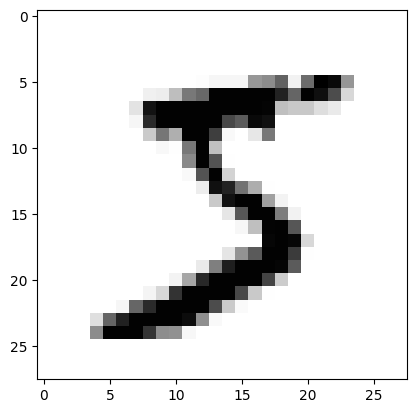

In [ ]:
# Antes tenía 8x8 pixels por imagen mientras que ahora tengo 28x28.
# Además tengo muchos más valores de escala de gris

import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));

Cada imagen se compone de 28x28 pixeles, y cada pixel representa una escala de grises que va del 0 al 255. Siendo 0 el blanco y 255 negro.

¿Se te ocurre alguna manera de normalizar los datos?

In [9]:
np.max(X_train)

np.uint8(255)

In [ ]:
0/255

In [10]:
128/255

0.5019607843137255

In [11]:
255/255

1.0

In [12]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

In [13]:
np.mean(X_train)

np.float32(0.13066047)

In [15]:
'''
Comprobamos la normalización
'''
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [16]:
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

Guardamos datos para validación. Estos datos se usarán durante el entrenamiento. Otra opción es decirle a keras en la etapa de entrenamiento que reserve un X % de los datos para validar.

In [17]:
X_val = X_train[-10000:]
y_val = y_train[-10000:]

X_train = X_train[:-10000]
y_train = y_train[:-10000]

In [19]:
# En redes neuronales no hay cross-validation (no como tal), para ello se dejan unas muestras para validation. 
# Y luego las de test
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)


Montamos la arquitectura de la red neuronal. Se va a componer de:
* **Sequential**: API para iniciar la red neuronal. No cuenta como capa.
* **Flatten**: capa de entrada. Necesita un vector unidimensional. Como tenemos imágenes, esta capa aplana las imagenes (2D) en 1D.
* **Dense**: es una hidden layer. Se compondrá de `n` neuronas y de una función de activación que se aplicará a todas las neuronas de la capa.

Recuerda que es un problema de clasificación multiclase (10 clases) y que por tanto la última capa se compondrá de tantas neuronas como clases tengas.

En cuanto a las funciones de activación es recomendable usar relu en las hidden layer, que tarda menos en entrenar, mientras que la ultima (output) suele ser una softmax.

In [ ]:
28*28

In [ ]:
X_train.shape

In [ ]:
# DEFINICIÓN DE LA RED NEURONAL

#Es un modelo secuencial: una capa detrás de otra
model = keras.models.Sequential()

# Capa entrada --> la primera capa es de aplanado (ya está definido para que no lo hagamos a mano)
model.add(keras.layers.Flatten(input_shape=(28, 28))) # son todas del mismo tamaño, si no habría que aplicar 
                                                      #técnicas de padding (o no se qué)

# Hidden layer --> los valores que nos da la gana
model.add(keras.layers.Dense(units = 300,
                            activation='relu'))

# Hidden layer --> los valores que nos da la gana
model.add(keras.layers.Dense(units = 100,
                            activation='relu'))

# Capa salida --> definido por el problema: son 10 clases las que quiero diferenciar y al ser una clasificación
# multiclase tiene que ser softmax (lo veremos)
model.add(keras.layers.Dense(units = 10,
                            activation='softmax'))

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Otra manera de declarar la misma red neuronal de arriba

capas = [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(units = 100, activation='relu'),
    keras.layers.Dense(units = 10, activation='softmax')
]

model = keras.models.Sequential(capas)

Podemos ver las capas, y acceder a sus elementos

In [ ]:
print(model.layers[0]) #me da la info de la primera capa

<Flatten name=flatten, built=True>


Podemos ver los pesos de las capas sin entrenar, porque los inicializa aleatoriamente. Los bias los inicializa a 0.

In [22]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()

In [ ]:
# se inicializa con pesos al azar
weights

array([[ 0.0041734 , -0.04083073,  0.01197254, ..., -0.01378302,
         0.05807129,  0.06593779],
       [-0.05644284,  0.03499122, -0.02600568, ..., -0.03993021,
        -0.0243532 ,  0.0724171 ],
       [-0.06799108, -0.05788521,  0.02434542, ..., -0.03992328,
         0.00416096,  0.03379951],
       ...,
       [-0.04678265, -0.05647169, -0.02244605, ..., -0.04346824,
         0.06502062,  0.06542064],
       [-0.01331089, -0.02276313, -0.05751125, ..., -0.01736967,
        -0.02787821, -0.06591456],
       [ 0.06859639, -0.02163254, -0.00420336, ...,  0.06341064,
         0.01360782,  0.01926178]], shape=(784, 300), dtype=float32)

In [ ]:
# 784 pesos en toda la red
len(weights)

784

In [ ]:
# pesos de la primera capa
len(weights[0])

In [ ]:
# Features que le meto a la entrada: 28x28 pixels
28*28

784

In [ ]:
# Ya tengo 235200 parámetros
300*784

235200

In [27]:
weights.size

235200

In [ ]:
# estos son los biases (parámetros tb) de las neuronas de la primera capa, que tb tendrá que  ajustar
len(biases)

300

Establecemos la configuración de ejecución... el compile.

In [29]:
model.compile(
    optimizer = keras.optimizers.SGD(), #Stocastic Gradient Descent
    loss = keras.losses.SparseCategoricalCrossentropy(), # es la función de pérdida a optimizar
    metrics = [keras.metrics.SparseCategoricalAccuracy()] # métrica
)

In [ ]:
# Equivalente
model.compile(
    optimizer = "sgd",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
# Summary
model.summary()
# La primera capa no tiene parámetros que ajustar
# La segunda ya hemos visto arriba los parámetros
# La tercera recibe 300 entradas, tiene sus 100 bias =300*100 + 100 =30100
# sucesivamente...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
784 * 300 + 300

In [ ]:
# 1º neurona de la 1º hidden layer
# y = a + w1*x1 + w2*x2 + .... wn*xn
# a es el intercepto llamado bias
# wn es cada uno de los pesos que va a ir actualizando con el backpropagation
# n es 784
# En la 1º hidden layer tenemos 784 pesos por cada neurona, al tener 300, tenemos un total de:
print(784*300 + 300)

In [ ]:
300 * 784 + 300

In [ ]:
300 * 100 + 100

In [ ]:
100 * 10 + 10

Entrenamos el modelo. Usamos los datos de entrenamiento. El batch_size es la cantidad de muestras que utiliza el SGD, y las epochs son las iteraciones que realiza en el entrenamiento.

In [31]:
X_train.shape

(50000, 28, 28)

In [ ]:
# Hay que definir el tamaño del lote de entrada. Normalmente por convención se hace en potencias de 2

50000/128

390.625

In [33]:
history = model.fit(
    X_train,
    y_train,
    batch_size = 128, # tamaño del lote
    epochs = 50,
    validation_data = (X_val, y_val) # validation_split = 0.1
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2546 - sparse_categorical_accuracy: 0.6859 - val_loss: 0.6097 - val_sparse_categorical_accuracy: 0.8550
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5212 - sparse_categorical_accuracy: 0.8650 - val_loss: 0.3992 - val_sparse_categorical_accuracy: 0.8965
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3990 - sparse_categorical_accuracy: 0.8912 - val_loss: 0.3340 - val_sparse_categorical_accuracy: 0.9102
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3480 - sparse_categorical_accuracy: 0.9037 - val_loss: 0.3025 - val_sparse_categorical_accuracy: 0.9154
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3178 - sparse_categorical_accuracy: 0.9103 - val_loss: 0.2808 - val_sparse_categorical_accuracy: 0.9211
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2962 - sparse_categorical_accuracy: 0.9163 - val_loss: 0.2649 - val_sparse_categorical_accuracy: 0.9243
Epoc

Podemos reentrenar el modelo. No empieza de nuevo, sino que retoma el entrenamiento anterior.

In [ ]:
# NO he perdido el entrenamiento anterior! Si reentreno, entrena ya sobre lo anterior
# Es lo que habilita el transfer learning: existen modelos ya pre-entrenados en cosas más genéricas que luego
# pueden seguir entrenándose para problemas más específicos

model.fit(
    X_train,
    y_train,
    batch_size = 64,
    epochs = 10,
    validation_data = (X_val, y_val) # validation_split = 0.1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0835 - sparse_categorical_accuracy: 0.9774 - val_loss: 0.1053 - val_sparse_categorical_accuracy: 0.9707
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0806 - sparse_categorical_accuracy: 0.9783 - val_loss: 0.1029 - val_sparse_categorical_accuracy: 0.9720
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0775 - sparse_categorical_accuracy: 0.9792 - val_loss: 0.1058 - val_sparse_categorical_accuracy: 0.9714
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0749 - sparse_categorical_accuracy: 0.9795 - val_loss: 0.0997 - val_sparse_categorical_accuracy: 0.9725
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0720 - sparse_categorical_accuracy: 0.9803 - val_loss: 0.0997 - val_sparse_categorical_accuracy: 0.9725
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0694 - sparse_categorical_accuracy: 0.9812 - val_loss: 0.0971 - val_sparse_categorical_accuracy: 0.9730
Epoc

Veamos el histórico del entrenamiento, para poder representarlo posteriormente.

In [35]:
# print(history.params)
# print(history.epoch)
print(history.history)

{'loss': [1.2545744180679321, 0.521207869052887, 0.39896127581596375, 0.3480342626571655, 0.3177957236766815, 0.2962088882923126, 0.27881139516830444, 0.26433616876602173, 0.25222423672676086, 0.24128147959709167, 0.23170773684978485, 0.2227887064218521, 0.2147233933210373, 0.20700275897979736, 0.2002423107624054, 0.193642720580101, 0.18738383054733276, 0.18156997859477997, 0.17624816298484802, 0.171009823679924, 0.16584216058254242, 0.16103143990039825, 0.15673737227916718, 0.15239675343036652, 0.14829282462596893, 0.14453579485416412, 0.14074140787124634, 0.1372501254081726, 0.13382279872894287, 0.13055796921253204, 0.12745527923107147, 0.12422999739646912, 0.12121041119098663, 0.11831457912921906, 0.1156759113073349, 0.11300744116306305, 0.1105850487947464, 0.10816670209169388, 0.1057172492146492, 0.10340575128793716, 0.1012050211429596, 0.09895943105220795, 0.09692848473787308, 0.09498710930347443, 0.09306608140468597, 0.09120785444974899, 0.08924183249473572, 0.08749856799840927, 

In [36]:
history.history

{'loss': [1.2545744180679321,
  0.521207869052887,
  0.39896127581596375,
  0.3480342626571655,
  0.3177957236766815,
  0.2962088882923126,
  0.27881139516830444,
  0.26433616876602173,
  0.25222423672676086,
  0.24128147959709167,
  0.23170773684978485,
  0.2227887064218521,
  0.2147233933210373,
  0.20700275897979736,
  0.2002423107624054,
  0.193642720580101,
  0.18738383054733276,
  0.18156997859477997,
  0.17624816298484802,
  0.171009823679924,
  0.16584216058254242,
  0.16103143990039825,
  0.15673737227916718,
  0.15239675343036652,
  0.14829282462596893,
  0.14453579485416412,
  0.14074140787124634,
  0.1372501254081726,
  0.13382279872894287,
  0.13055796921253204,
  0.12745527923107147,
  0.12422999739646912,
  0.12121041119098663,
  0.11831457912921906,
  0.1156759113073349,
  0.11300744116306305,
  0.1105850487947464,
  0.10816670209169388,
  0.1057172492146492,
  0.10340575128793716,
  0.1012050211429596,
  0.09895943105220795,
  0.09692848473787308,
  0.09498710930347443

In [ ]:
history.history.keys()

In [37]:
pd.DataFrame(history.history)

,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
0,1.254574,0.68590,0.609732,0.8550
1,0.521208,0.86504,0.399229,0.8965
2,0.398961,0.89116,0.334027,0.9102
3,0.348034,0.90372,0.302499,0.9154
4,0.317796,0.91026,0.280835,0.9211
5,0.296209,0.91634,0.264899,0.9243
6,0.278811,0.92182,0.250707,0.9283
7,0.264336,0.92536,0.241046,0.9311
8,0.252224,0.92928,0.229985,0.9341
9,0.241281,0.93234,0.223111,0.9362


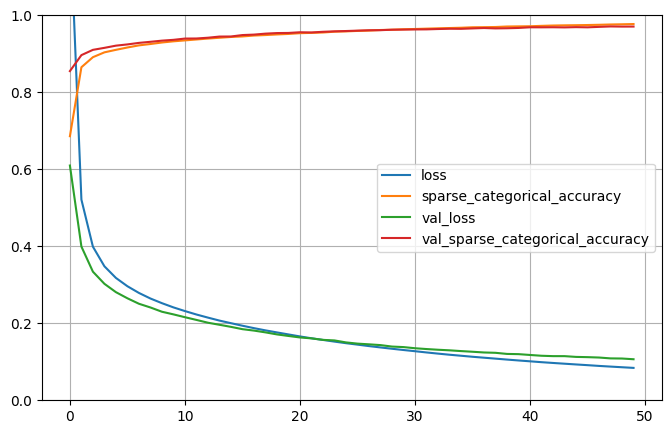

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Si el modelo no ha ido bien, prueba a cambiar el learning rate, cambia de optimizador y después prueba a cambiar capas, neuronas y funciones de activación.

Ya tenemos el modelo entrenado. Probémoslo con test

In [ ]:
# Estas muestras no las había visto nunca
results = model.evaluate(X_test, y_test)
results

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0932 - sparse_categorical_accuracy: 0.9714


[0.09324795007705688, 0.9714000225067139]

C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_7648\1468152043.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


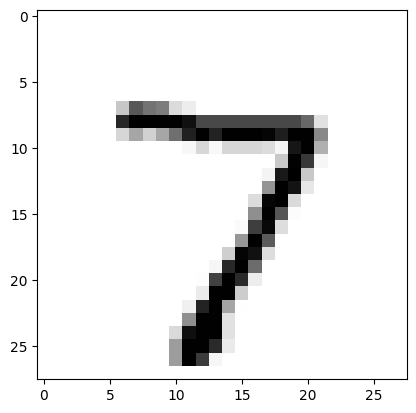

In [40]:
# Cogemos el primero
plt.imshow(X_test[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [41]:
X_test[:1]

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

In [ ]:
predictions = model.predict(X_test[:1])
print(predictions.shape)
predictions # veo las probabilidades de que sea un 0, 1, 2, 3,... etc. La más alta es un 7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
(1, 10)


array([[6.1529258e-06, 5.9527991e-07, 3.8130430e-04, 2.1344125e-03,
        6.9533399e-08, 1.3611650e-06, 1.2682951e-10, 9.9744558e-01,
        1.7812685e-06, 2.8671389e-05]], dtype=float32)

In [43]:
predictions.argmax()

np.int64(7)

In [ ]:
model.predict(X_test).argmax(axis=1)
# Me da las clases que predice con probabilidad de mayor a menor

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_7648\4029188365.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[1].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


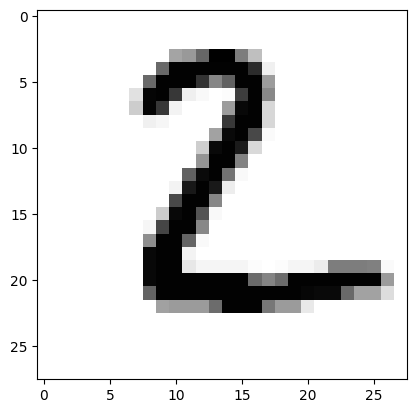

In [45]:
plt.imshow(X_test[1].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test).argmax(axis=1))
# QUé confunde con qué

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[ 970,    0,    0,    0,    1,    1,    1,    2,    2,    3],
       [   0, 1126,    2,    1,    0,    1,    2,    0,    3,    0],
       [   4,    2, 1006,    3,    1,    1,    2,    5,    8,    0],
       [   0,    0,    2,  988,    0,    7,    0,    4,    4,    5],
       [   1,    0,    4,    1,  949,    0,    1,    2,    1,   23],
       [   4,    1,    0,    6,    1,  864,    8,    0,    4,    4],
       [   5,    3,    1,    1,    9,    7,  929,    0,    3,    0],
       [   1,   10,    9,    8,    0,    1,    0,  977,    1,   21],
       [   5,    0,    3,   15,    4,    7,    3,    2,  929,    6],
       [   3,    3,    1,    8,    9,    2,    1,    5,    1,  976]])

### Problema de regresión
Veamos un ejemplo de cómo aplicar una red neuronal de TensorFlow a un problema de regresión.

In [47]:
# Cargamos datos
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns = housing.feature_names)
df['target'] = housing['target']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Divimos en train, test y validation

In [48]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data,
                                                              housing.target)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,
                                                      y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [49]:
X_train.shape

(11610, 8)

Montamos el modelo. Simplemente se compondrá de una hidden layer, a la que le configuramos una capa previa de entrada de 8 neuronas (las features).

Se trata de un modelo de regresión, por lo que la capa de salida es una única neurona.

In [ ]:
11610/32

In [ ]:
X_train.shape

In [ ]:
X_train.shape[1:]

In [50]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',
                      input_shape = X_train.shape[1:]),
    keras.layers.Dense(1) # como predigo un número es 1, no tiene capa de activación porque es regresión
])

model.compile(loss = "mean_squared_error", # función de coste
             optimizer = "sgd") #optimizador

history = model.fit(X_train,
                   y_train,
                   epochs = 20,
                   validation_data = (X_valid, y_valid))

Epoch 1/20


c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7701 - val_loss: 27.1238
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5964 - val_loss: 0.5188
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4627 - val_loss: 0.4852
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4337 - val_loss: 0.4128
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4025 - val_loss: 0.4009
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4028 - val_loss: 0.3858
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3834 - val_loss: 0.3784
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3765 - val_loss: 0.3728
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3849 - val_loss: 0.3786
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3759 - val_loss: 0.3671
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3686 - val_loss: 0.3630
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0

In [ ]:
8*30 + 30

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.19 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
8*30+30

In [52]:
mse_test = model.evaluate(X_test, y_test)
print(mse_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3643
0.3642628788948059


In [53]:
y_pred = model.predict(X_test[:5])
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[3.0655503],
       [4.077861 ],
       [1.4286833],
       [2.539246 ],
       [4.2465467]], dtype=float32)

### Guardar modelo
Para guardar el modelo, en el formato de Keras (HDF5). 

In [54]:
model.save("my_keras_model.keras")

In [55]:
# Lo volvemos a cargar
model = keras.models.load_model("my_keras_model.keras")

### Callbacks
Son funciones predefinidas de Keras a aplicar durante el entrenamiento
Por ejemplo, `ModelCheckpoint` sirve para que el modelo se vaya guardando tras cada epoch. Así no perdemos el progreso en caso de que decidamos interrumpir el entrenamiento. El callback recibe como argumento el nombre del objeto donde queremos que se guarde el modelo entrenado.

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("callback_model.keras")
history = model.fit(X_train,
                   y_train,
                   epochs=30,
                   callbacks = [checkpoint_cb]) # checkpoint - va guardando cada epoch. Así, si peta el pc al menos 
                                                # tenemos guardado hasta ese punto

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3443
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3422  
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3391
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3375
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3353
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3344  
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3337  
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3318
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3328
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3281  
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3267
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3259  
Epoch 13/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3252
Epoch 14/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3282
Epoch 15/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms

### Early Stopping
Interrumpe el entrenamiento cuando no ve progreso en el set de validación. Para ello tiene en cuenta un numero de epochs llamado `patience`. Se puede combinar con el callback

In [57]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10) # Si hace 10 iteraciones en las que no mejores significativamente (configurable), para
history = model.fit(X_train,
                   y_train,
                   epochs=50,
                   validation_data = (X_valid, y_valid),
                   callbacks = [early_stopping_cb, checkpoint_cb])

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3054 - val_loss: 0.3473
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3065 - val_loss: 0.3284
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3093 - val_loss: 0.3434
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3080 - val_loss: 0.3358
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3072 - val_loss: 0.3433
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3063 - val_loss: 0.3393
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3047 - val_loss: 0.3325
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3030 - val_loss: 0.3360
Epoch 9/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3029 - val_loss: 0.3437
Epoch 10/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3026 - val_loss: 0.3260
Epoch 11/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3066 - val_loss: 0.3350
Epoch 12/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
#Ha parado en el 42, cuando le había marcado 30. 

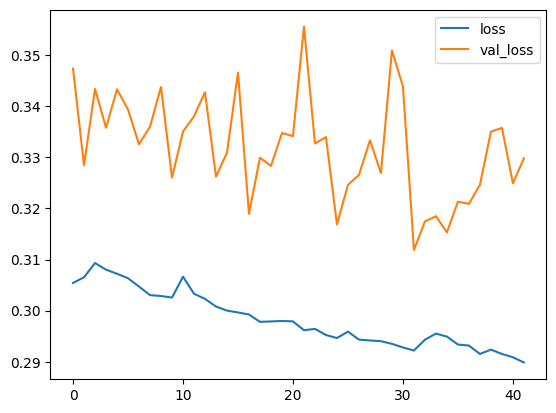

In [58]:
history_df = pd.DataFrame(history.history).plot()